# 07 — Fusão multimodal (capstone)

In [1]:
%matplotlib inline
import sys, json
sys.path.insert(0, '..')
import pandas as pd
from pathlib import Path
from IPython.display import Image, display, Markdown
from src import config as C, data
LABELS = data.get_label_names()

def load(name):
    p = C.METRICS_DIR / name
    return json.loads(p.read_text()) if p.exists() else None

ens, moe, xm = load('ensemble.json'), load('moe.json'), load('crossmodal.json')
print('ensemble:', ens is not None, '| moe:', moe is not None, '| crossmodal:', xm is not None)

ensemble: True | moe: True | crossmodal: True


In [2]:
rows = []
if ens:
    for k, v in ens['individual'].items():
        rows.append(('isolado', k, v['accuracy'], v['macro_f1']))
    for k, v in ens['ensembles'].items():
        rows.append(('late-fusion', k, v['accuracy'], v['macro_f1']))
if moe:
    for k, v in moe['methods_acc'].items():
        rows.append(('MoE / roteamento', k, v, None))
if xm:
    cm = xm['crossmodal_fusion']
    rows.append(('cross-modal (E2E)', 'transformer_fusao', cm['accuracy'], cm['macro_f1']))
    rows.append(('referencia', 'teto_oraculo', xm['oracle_any_correct'], None))
elif moe:
    rows.append(('referencia', 'teto_oraculo', moe['oracle_any_correct'], None))

df = pd.DataFrame(rows, columns=['grupo', 'metodo', 'acc', 'macro_f1'])
df.sort_values('acc').reset_index(drop=True)

,grupo,metodo,acc,macro_f1
0,isolado,layoutlmv3,0.874687,0.874379
1,late-fusion,soft_avg_dit_ll,0.897188,0.896942
2,cross-modal (E2E),transformer_fusao,0.930000,0.929939
3,isolado,dit_vision,0.932187,0.932308
4,late-fusion,soft_weighted_dit_ll,0.935625,0.935721
5,MoE / roteamento,stacking_gb,0.938750,NaN
6,MoE / roteamento,soft_moe_gate,0.945312,NaN
7,MoE / roteamento,soft_avg_3,0.947187,NaN
8,MoE / roteamento,per_class_weighted,0.948750,NaN
9,MoE / roteamento,hard_router,0.949375,NaN


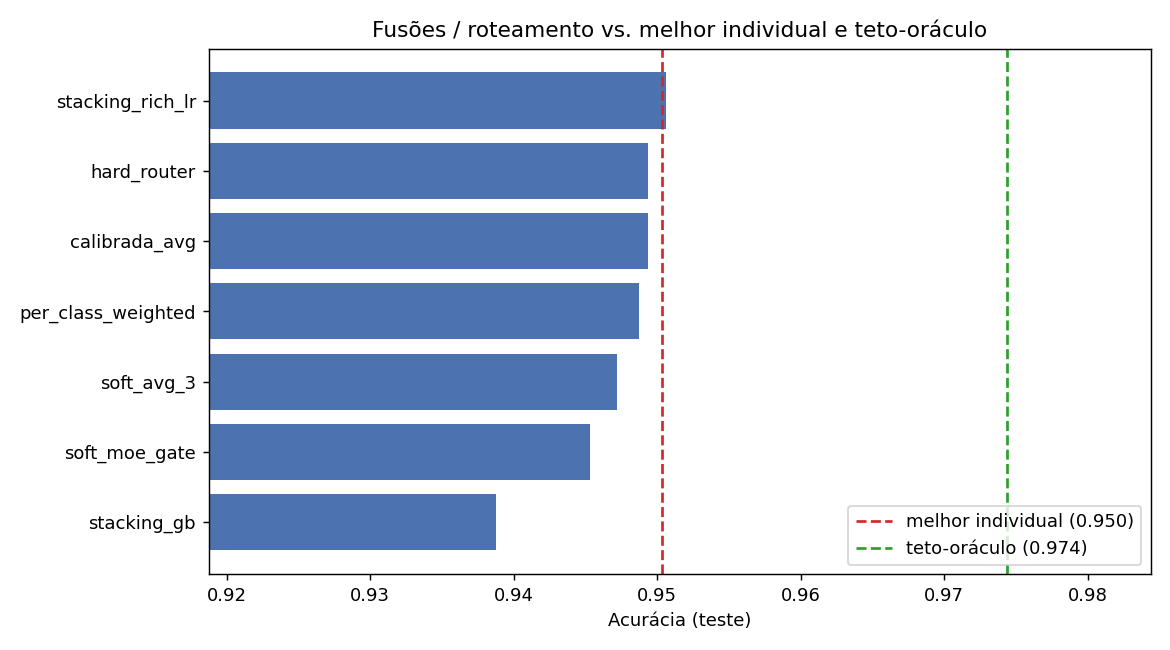

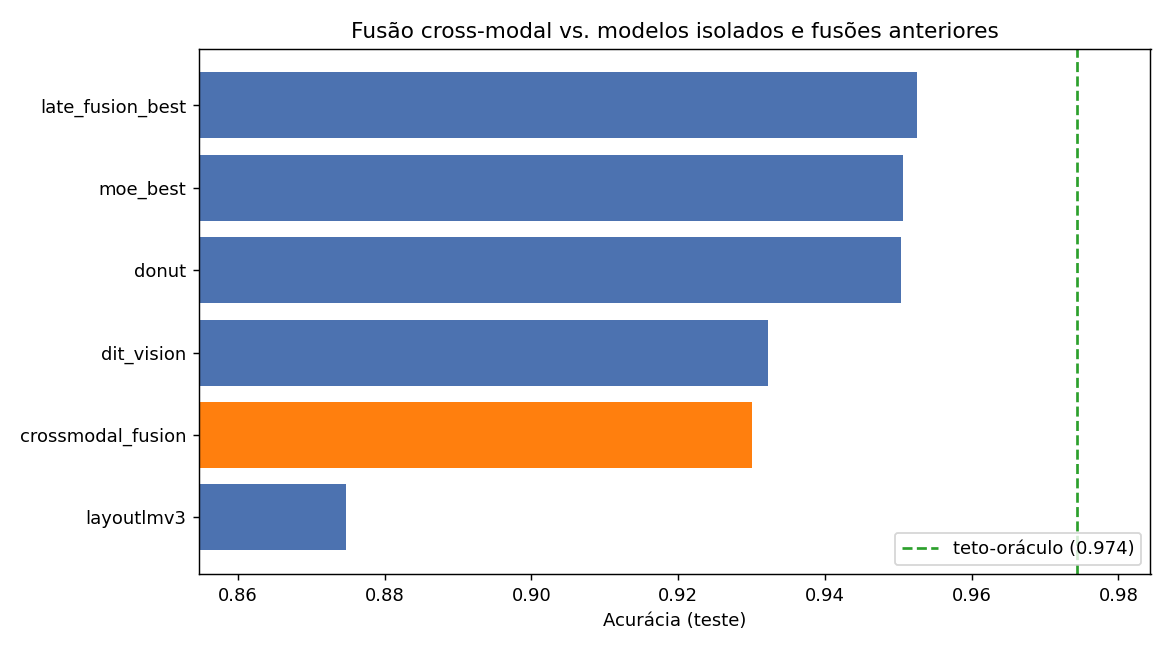

In [3]:
for fn in ['moe_methods.png', 'crossmodal_comparison.png']:
    fp = C.PLOTS_DIR / fn
    display(Image(filename=str(fp))) if fp.exists() else print(fn, 'pendente.')

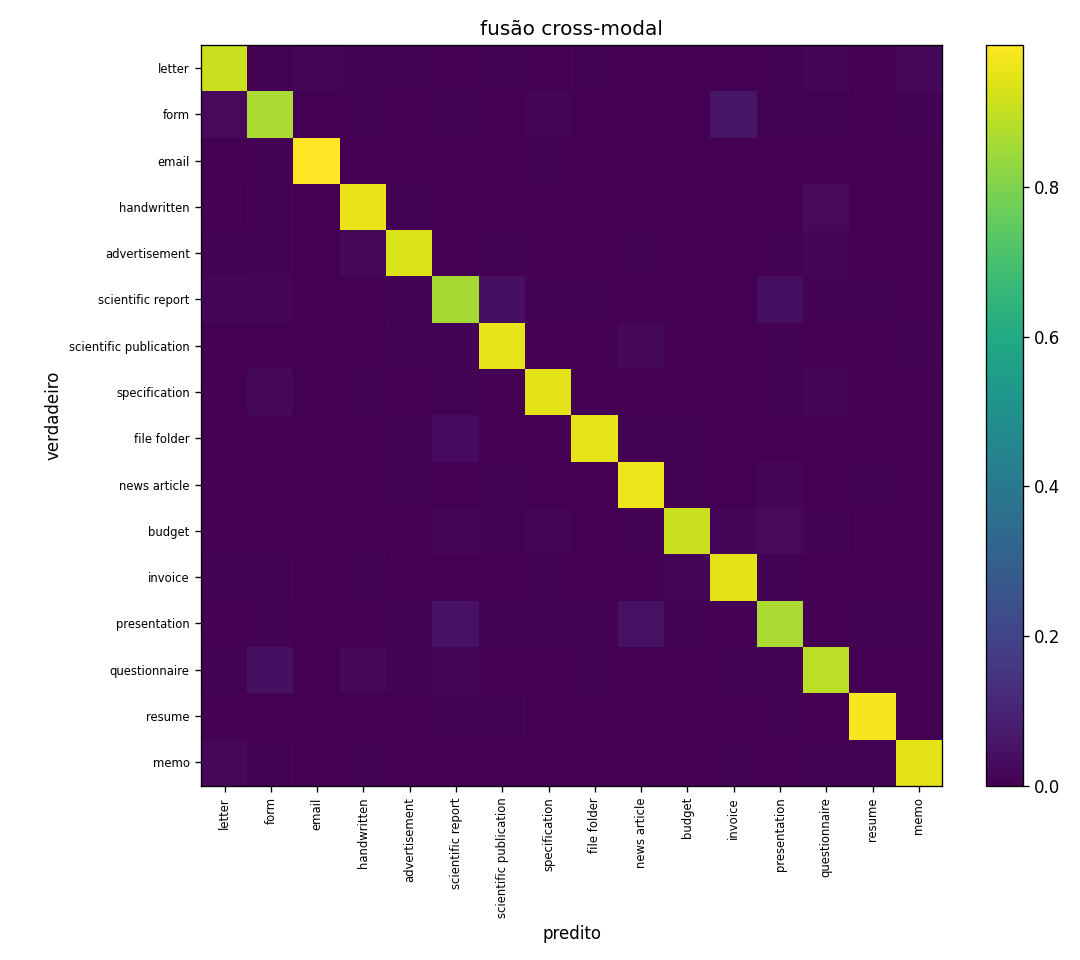

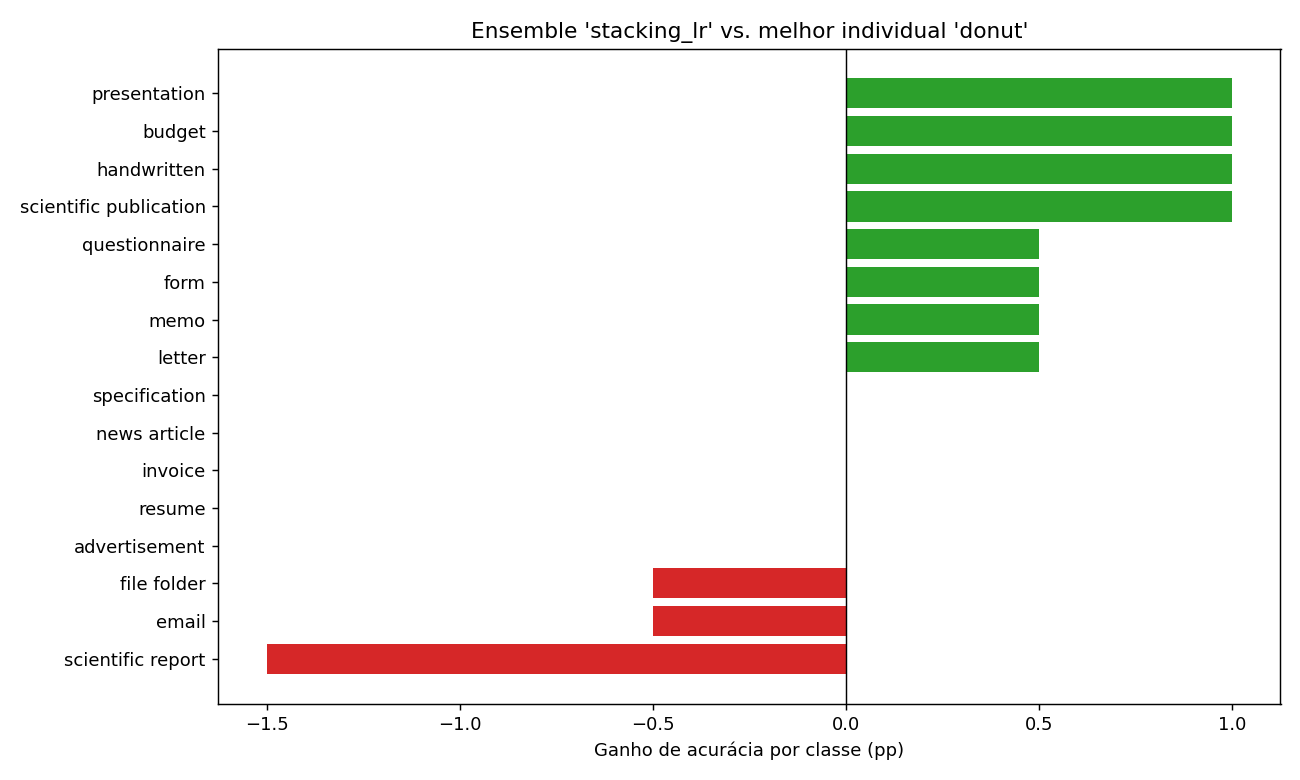

In [4]:
for fn in ['crossmodal_confusion.png', 'ensemble_perclass_gain.png']:
    fp = C.PLOTS_DIR / fn
    display(Image(filename=str(fp))) if fp.exists() else print(fn, 'pendente.')

In [5]:
if ens:
    print('concordância par-a-par:', ens['pairwise_agreement'])
if moe:
    print('peso médio do soft-gate:', {k: round(v, 3) for k, v in moe['gate_mean_weight'].items()})
    print('router escolhe:', {k: round(v, 3) for k, v in moe['router_pick_rate'].items()})
    print('temperaturas:', moe['temperatures'])

concordância par-a-par: {'dit_vs_ll': 0.8728125, 'dit_vs_donut': 0.941875, 'll_vs_donut': 0.8815625}
peso médio do soft-gate: {'dit': 0.135, 'll': 0.794, 'dn': 0.07}
router escolhe: {'dit': 0.013, 'll': 0.878, 'dn': 0.11}
temperaturas: {'dit': 0.8, 'll': 1.8, 'dn': None}
